# EPA Environmental Confounder Analysis

## Objective
This notebook analyzes EPA monitor-level concentration data to identify environmental measurements of lead, barium, and antimony, which are key elements in gunshot residue (GSR). The goal is to assess whether these elements appear in ambient particulate matter strongly enough to act as environmental confounders and increase the risk of false positives in machine learning-based GSR classification.

In [1]:
import pandas as pd

file_path = "../../data/raw/annual_conc_by_monitor_2025.csv"
df = pd.read_csv(file_path)

print(df.columns.tolist())
df.head()

['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Metric Used', 'Method Name', 'Year', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Completeness Indicator', 'Valid Day Count', 'Required Day Count', 'Exceptional Data Count', 'Null Data Count', 'Primary Exceedance Count', 'Secondary Exceedance Count', 'Certification Indicator', 'Num Obs Below MDL', 'Arithmetic Mean', 'Arithmetic Standard Dev', '1st Max Value', '1st Max DateTime', '2nd Max Value', '2nd Max DateTime', '3rd Max Value', '3rd Max DateTime', '4th Max Value', '4th Max DateTime', '1st Max Non Overlapping Value', '1st NO Max DateTime', '2nd Max Non Overlapping Value', '2nd NO Max DateTime', '99th Percentile', '98th Percentile', '95th Percentile', '90th Percentile', '75th Percentile', '50th Percentile', '10th Percentile', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Na

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,75th Percentile,50th Percentile,10th Percentile,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.054,0.045,0.029,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.040,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.040,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.040,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
4,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,10.000,6.000,1.000,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29


## Initial Data Inspection
The EPA file is loaded in long format, where each row represents a pollutant measurement for a specific monitoring context rather than one row per region. This requires filtering and reshaping before capstone-relevant analysis can be performed.

In [2]:
relevant = [p for p in df["Parameter Name"].dropna().unique()
            if "PM2.5" in p or "PM10" in p or "Lead" in p or "Barium" in p or "Antimony" in p]

sorted(relevant)

['Acceptable PM2.5 AQI & Speciation Mass',
 'Aluminum PM2.5 LC',
 'Ammonium Ion PM2.5 LC',
 'Ammonium Nitrate PM2.5 LC',
 'Ammonium Sulfate PM2.5 LC',
 'Antimony (TSP) STP',
 'Antimony PM10 LC',
 'Antimony PM10 STP',
 'Antimony PM2.5 LC',
 'Arsenic PM10 LC',
 'Arsenic PM10 STP',
 'Arsenic PM2.5 LC',
 'Barium PM10 LC',
 'Barium PM2.5 LC',
 'Beryllium PM10 LC',
 'Beryllium PM10 STP',
 'Black Carbon  PM2.5 Corrected',
 'Black Carbon PM2.5 at 880 nm',
 'Black carbon PM2.5 STP',
 'Bromine PM2.5 LC',
 'Cadmium PM10 LC',
 'Cadmium PM10 STP',
 'Cadmium PM2.5 LC',
 'Calcium PM2.5 LC',
 'Cerium PM2.5 LC',
 'Cesium PM2.5 LC',
 'Chloride PM10 STP',
 'Chloride PM2.5 LC',
 'Chlorine PM2.5 LC',
 'Chromium PM10 LC',
 'Chromium PM10 STP',
 'Chromium PM2.5 LC',
 'Cobalt PM10 LC',
 'Cobalt PM10 STP',
 'Cobalt PM2.5 LC',
 'Copper PM10 LC',
 'Copper PM2.5 LC',
 'EC CSN PM2.5 LC TOT',
 'EC CSN_Rev Unadjusted PM2.5 LC TOR',
 'EC CSN_Rev Unadjusted PM2.5 LC TOT',
 'EC PM2.5 LC TOR',
 'EC PM2.5 LC TOT',
 'EC1 

## Filter to Capstone-Relevant Parameters
The notebook now narrows the EPA dataset to environmental measures most relevant to possible GSR confounding:
- particulate burden: PM2.5 and PM10
- GSR-overlap elements: lead, barium, antimony

In [3]:
target_params = [
    "PM2.5 - Local Conditions",
    "PM10 Total 0-10um STP",
    "Lead PM2.5 LC",
    "Barium PM2.5 LC",
    "Antimony PM2.5 LC"
]

df_capstone = df[df["Parameter Name"].isin(target_params)].copy()

df_pivot = df_capstone.pivot_table(
    index="CBSA Name",
    columns="Parameter Name",
    values="Arithmetic Mean",
    aggfunc="mean"
).reset_index()

df_pivot.head()

Parameter Name,CBSA Name,Antimony PM2.5 LC,Barium PM2.5 LC,Lead PM2.5 LC,PM10 Total 0-10um STP,PM2.5 - Local Conditions
0,"Aberdeen, SD",NaN,NaN,NaN,19.299869,5.309732
1,"Adrian, MI",NaN,NaN,NaN,NaN,7.636279
2,"Akron, OH",0.000115,0.0025,0.002731,16.335577,8.589505
3,"Albany, GA",NaN,NaN,NaN,NaN,9.396718
4,"Albany-Schenectady-Troy, NY",0.000083,0.0015,0.002542,NaN,7.278921


The data is aggregated to the CBSA level so each metropolitan area has a summarized environmental profile. This provides a regional view of environmental exposure to GSR-relevant elements.

In [4]:
df_pivot.columns.name = None

df_pivot = df_pivot.rename(columns={
    "PM2.5 - Local Conditions": "PM25",
    "PM10 Total 0-10um STP": "PM10",
    "PM10 - LC": "PM10_LC",
    "Lead PM2.5 LC": "Lead_PM25",
    "Barium PM2.5 LC": "Barium_PM25",
    "Antimony PM2.5 LC": "Antimony_PM25"
})

df_pivot.head()

,CBSA Name,Antimony_PM25,Barium_PM25,Lead_PM25,PM10,PM25
0,"Aberdeen, SD",NaN,NaN,NaN,19.299869,5.309732
1,"Adrian, MI",NaN,NaN,NaN,NaN,7.636279
2,"Akron, OH",0.000115,0.0025,0.002731,16.335577,8.589505
3,"Albany, GA",NaN,NaN,NaN,NaN,9.396718
4,"Albany-Schenectady-Troy, NY",0.000083,0.0015,0.002542,NaN,7.278921


Renaming simplifies the variable names and makes later analysis easier to interpret in tables, charts, and report language.

In [5]:
df_pivot.isna().sum().sort_values()

CBSA Name          0
PM25              44
PM10             209
Lead_PM25        260
Barium_PM25      322
Antimony_PM25    322
dtype: int64

## Data Coverage Check
This step evaluates which relevant measures are widely available and which are sparse. Missingness matters because environmental background levels may be unevenly measured across regions.

In [6]:
for col in ["PM25", "PM10", "Lead_PM25", "Barium_PM25", "Antimony_PM25"]:
    if col in df_pivot.columns:
        df_pivot[col] = df_pivot[col].fillna(0)

for col in ["PM25", "PM10", "Lead_PM25", "Barium_PM25", "Antimony_PM25"]:
    if col in df_pivot.columns and df_pivot[col].max() > 0:
        df_pivot[col + "_norm"] = df_pivot[col] / df_pivot[col].max()

## Standardization
Variables are normalized so that particulate measures and elemental concentrations can be combined into a single composite score without one variable dominating purely because of scale.

In [7]:
df_pivot["GSR_Confounder_Score"] = (
    0.35 * df_pivot.get("PM25_norm", 0) +
    0.20 * df_pivot.get("PM10_norm", 0) +
    0.20 * df_pivot.get("Lead_PM25_norm", 0) +
    0.15 * df_pivot.get("Barium_PM25_norm", 0) +
    0.10 * df_pivot.get("Antimony_PM25_norm", 0)
)

## Construct Environmental Confounder Score
This score estimates how strongly a regional environmental profile could resemble GSR-related chemistry. Higher values indicate greater potential for environmental overlap with Pb-Ba-Sb patterns that may contribute to false positives.

In [8]:
df_pivot.sort_values("GSR_Confounder_Score", ascending=False)[
    ["CBSA Name", "PM25", "PM10", "Lead_PM25", "Barium_PM25", "Antimony_PM25", "GSR_Confounder_Score"]
].head(15)

,CBSA Name,PM25,PM10,Lead_PM25,Barium_PM25,Antimony_PM25,GSR_Confounder_Score
124,"El Paso, TX",18.884573,119.089412,0.002960,0.007340,0.002740,0.654778
239,"Los Angeles-Long Beach-Anaheim, CA",10.998848,25.347827,0.011417,0.013229,0.000729,0.524039
122,"El Centro, CA",6.337026,47.452495,0.008345,0.007862,0.023690,0.487627
299,"Phoenix-Mesa-Scottsdale, AZ",8.263301,39.131796,0.003770,0.026620,0.000160,0.435585
279,"Nogales, AZ",10.755342,44.288652,0.007950,0.000000,0.000000,0.412981
227,"Las Cruces, NM",13.908829,55.378413,0.000000,0.000000,0.000000,0.350784
265,"Modesto, CA",8.172994,20.252902,0.002851,0.004362,0.021489,0.350720
79,"Chico, CA",8.059820,19.380409,0.002383,0.003681,0.020511,0.330993
402,"Visalia-Porterville, CA",7.411913,25.925792,0.001648,0.004362,0.022468,0.329191
189,"Houston-The Woodlands-Sugar Land, TX",10.377586,37.573747,0.001489,0.005374,0.000138,0.312385


## Interpretation
The highest-ranked CBSAs represent regions where ambient particulate matter and GSR-relevant elemental composition may overlap most strongly. These locations can be discussed as potential high-risk environments for false positives in forensic classification workflows.

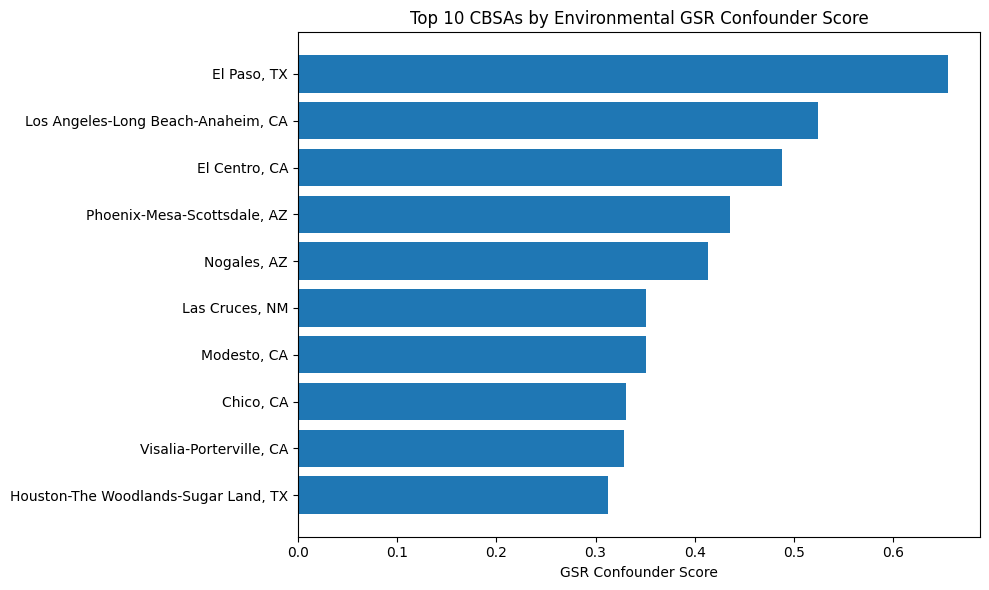

In [9]:
import matplotlib.pyplot as plt

top = df_pivot.sort_values("GSR_Confounder_Score", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top["CBSA Name"], top["GSR_Confounder_Score"])
plt.xlabel("GSR Confounder Score")
plt.title("Top 10 CBSAs by Environmental GSR Confounder Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This figure highlights the metropolitan areas with the strongest environmental overlap with GSR-relevant chemistry. These results can support the argument that environmental particles may create non-trivial background conditions for automated GSR classification.

## Validation Check
This confirms the exact metal-related parameter names present in the EPA data and documents the environmental availability of lead, barium, and antimony measures.

In [10]:
[p for p in sorted(df["Parameter Name"].dropna().unique())
 if "Lead" in p or "Barium" in p or "Antimony" in p]

['Antimony (TSP) STP',
 'Antimony PM10 LC',
 'Antimony PM10 STP',
 'Antimony PM2.5 LC',
 'Barium PM10 LC',
 'Barium PM2.5 LC',
 'Lead (TSP) LC',
 'Lead (TSP) LC Non-FRM/FEM',
 'Lead (TSP) STP',
 'Lead PM10 LC',
 'Lead PM10 STP',
 'Lead PM2.5 LC']